# Notebook 01 - Exploration des données sur le diabète et modèles de classification

Ce notebook explore l'ensemble de données sur le diabète des Indiens Pima, nettoie les données, effectue une analyse exploratoire des données (EDA), conçoit des caractéristiques, entraîne plusieurs modèles de classification et compare leurs performances.

## 1. Load and Explore the Dataset

In [15]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

base_dir = Path.cwd().resolve()
if base_dir.name == "notebooks":
    project_dir = base_dir.parent
else:
    project_dir = base_dir

data_path = project_dir / "data" / "diabetes.csv"
raw_df = pd.read_csv(data_path)

print(f"Loaded dataset from: {data_path}")
print(f"Shape: {raw_df.shape}")
print("\nFirst rows:")
display(raw_df.head())
print("\nData types:")
display(raw_df.dtypes.to_frame("dtype"))
print("\nSummary info:")
raw_df.info()

Loaded dataset from: D:\Education\M2 - IA - NEXA\S2\05. Introduction aux modèles IA génératives - TRONC\intelligent-backend\data\diabetes.csv
Shape: (768, 9)

First rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Data types:


,dtype
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64



Summary info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 2. Data Preprocessing and Cleaning

In [16]:
clean_df = raw_df.copy()

zero_missing_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

print("Duplicate rows before cleaning:", clean_df.duplicated().sum())
print("Zero counts by feature:")
for column in zero_missing_columns:
    print(f"  {column}: {(clean_df[column] == 0).sum()}")

clean_df = clean_df.drop_duplicates().reset_index(drop=True)
clean_df[zero_missing_columns] = clean_df[zero_missing_columns].replace(0, np.nan)

median_values = clean_df[zero_missing_columns].median(numeric_only=True)
clean_df[zero_missing_columns] = clean_df[zero_missing_columns].fillna(median_values)

print("\nMissing values after imputation:")
display(clean_df.isna().sum().to_frame("missing_count"))

clean_path = project_dir / "data" / "diabetes_clean.csv"
clean_df.to_csv(clean_path, index=False)
print(f"Cleaned dataset saved to: {clean_path}")
display(clean_df.head())

Duplicate rows before cleaning: 0
Zero counts by feature:
  Glucose: 5
  BloodPressure: 35
  SkinThickness: 227
  Insulin: 374
  BMI: 11

Missing values after imputation:


,missing_count
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Cleaned dataset saved to: D:\Education\M2 - IA - NEXA\S2\05. Introduction aux modèles IA génératives - TRONC\intelligent-backend\data\diabetes_clean.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


## 3. Exploratory Data Analysis (EDA)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


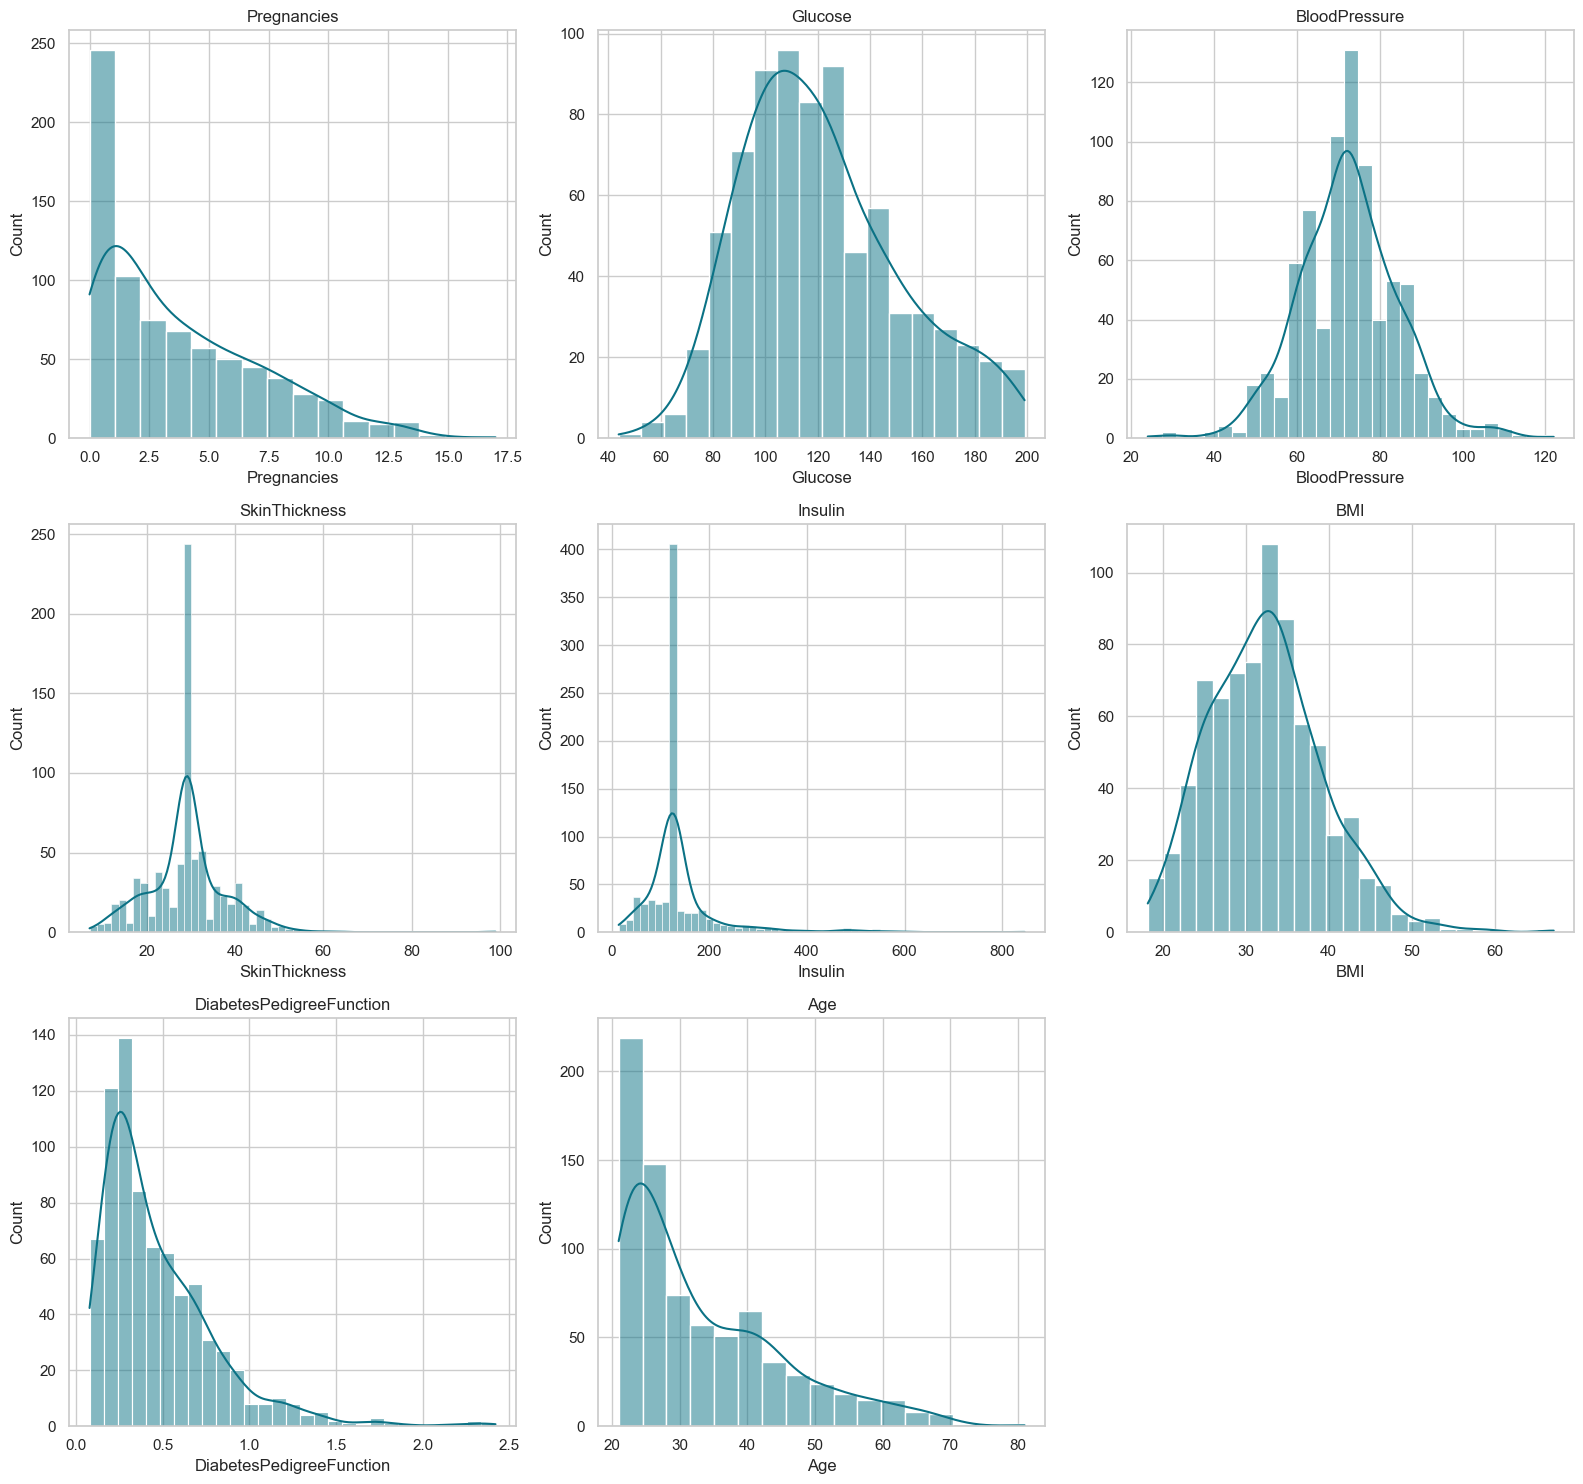

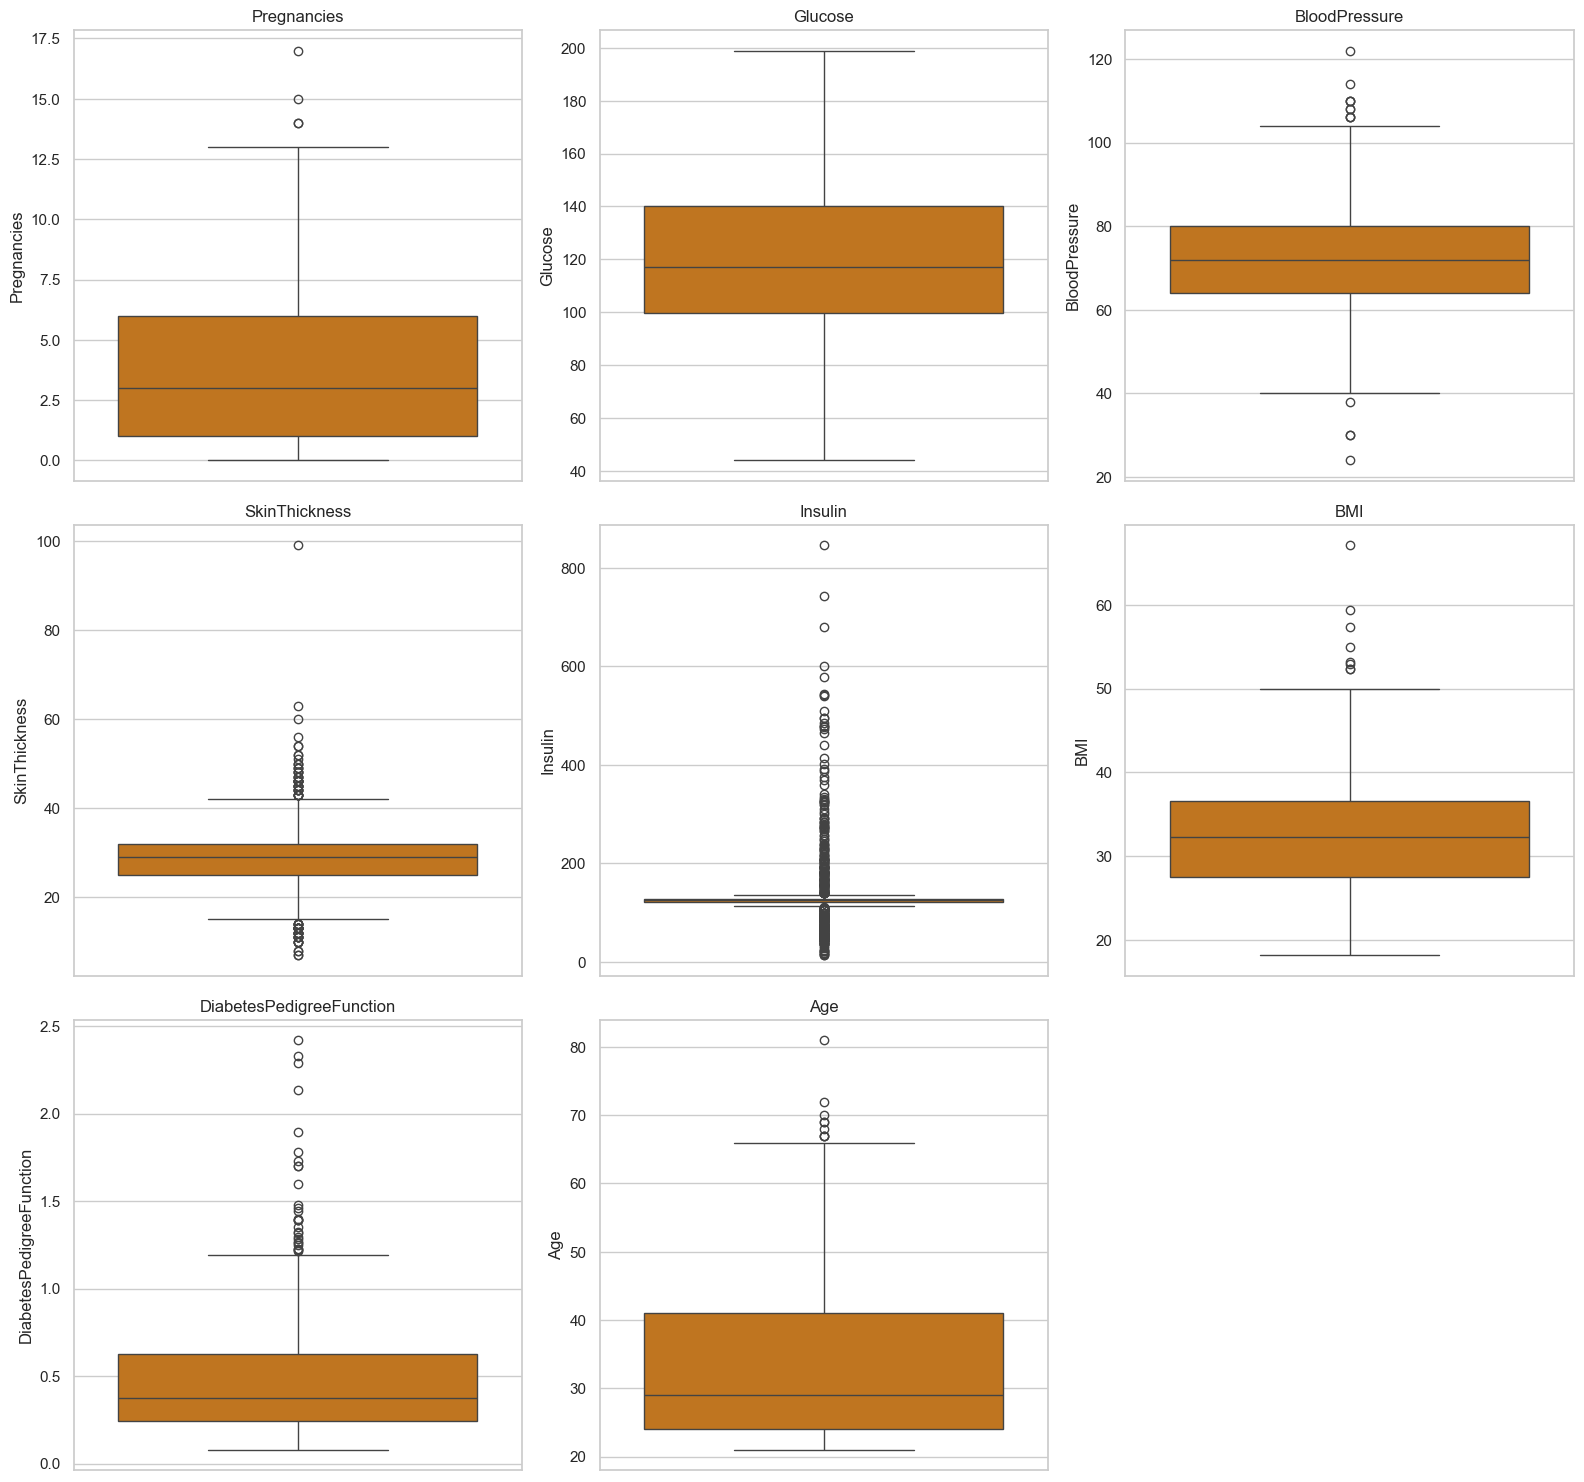

C:\Users\ACER\AppData\Local\Temp\ipykernel_20316\959053583.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clean_df, x="Outcome", palette="Set2")


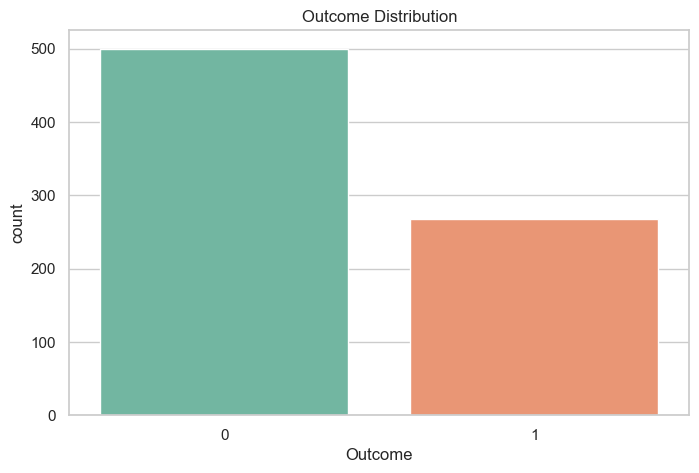

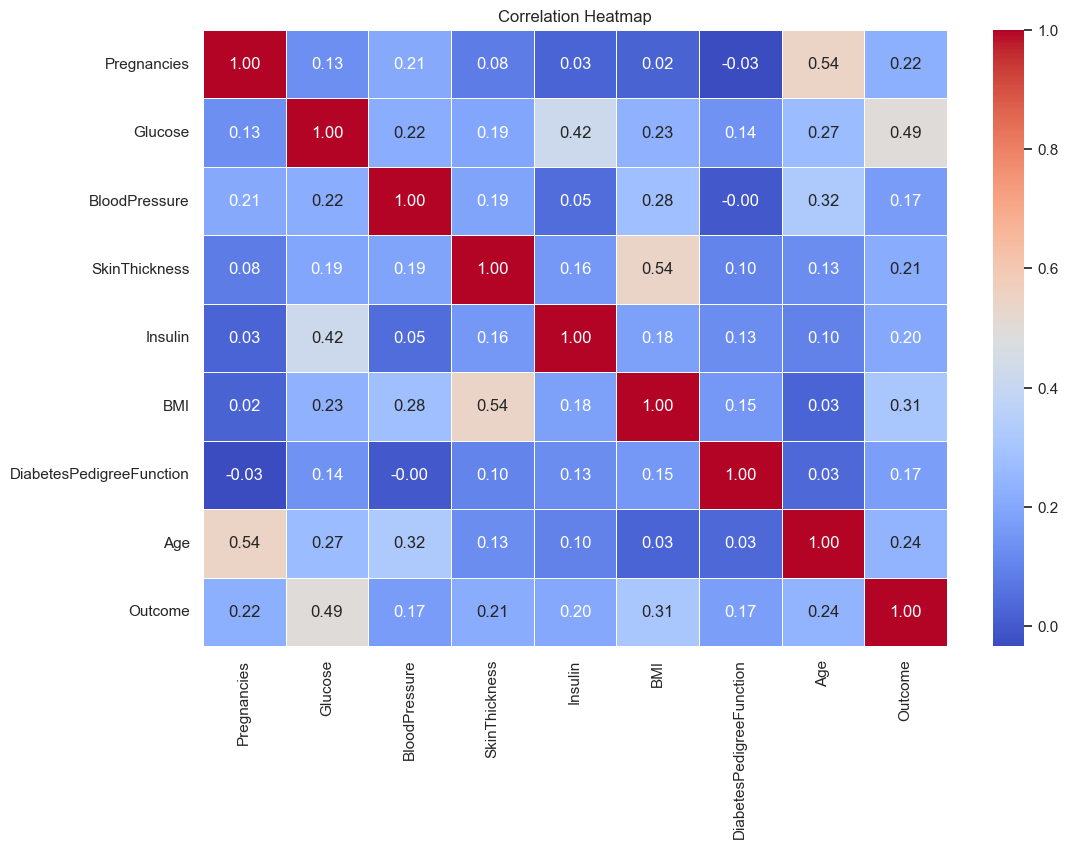

In [17]:
display(clean_df.describe().T)

feature_columns = clean_df.columns[:-1]
n_features = len(feature_columns)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()
for idx, column in enumerate(feature_columns):
    sns.histplot(clean_df[column], kde=True, ax=axes[idx], color="#0b7285")
    axes[idx].set_title(column)
for ax in axes[n_features:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()
for idx, column in enumerate(feature_columns):
    sns.boxplot(y=clean_df[column], ax=axes[idx], color="#d97706")
    axes[idx].set_title(column)
for ax in axes[n_features:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=clean_df, x="Outcome", palette="Set2")
plt.title("Outcome Distribution")
plt.show()

plt.figure(figsize=(12, 8))
corr_matrix = clean_df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## 4. Feature Engineering

In [18]:
engineered_df = clean_df.copy()
engineered_df["Glucose_BMI_Ratio"] = engineered_df["Glucose"] / (engineered_df["BMI"] + 1e-6)
engineered_df["Glucose_Insulin_Ratio"] = engineered_df["Glucose"] / (engineered_df["Insulin"] + 1e-6)
engineered_df["Age_BMI_Product"] = engineered_df["Age"] * engineered_df["BMI"]
engineered_df["BloodPressure_BMI_Ratio"] = engineered_df["BloodPressure"] / (engineered_df["BMI"] + 1e-6)
engineered_df["Pregnancy_Age_Index"] = engineered_df["Pregnancies"] * engineered_df["Age"]

feature_columns = [column for column in engineered_df.columns if column != "Outcome"]
X = engineered_df[feature_columns]
y = engineered_df["Outcome"]

## 5. Train-Test Split

In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

saved_models_dir = project_dir / "saved_models"
saved_models_dir.mkdir(parents=True, exist_ok=True)
scaler_path = saved_models_dir / "scaler.pkl"
joblib.dump(scaler, scaler_path)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Scaler saved to: {scaler_path}")
display(X_train.head())

Train shape: (537, 13)
Validation shape: (115, 13)
Test shape: (116, 13)
Scaler saved to: D:\Education\M2 - IA - NEXA\S2\05. Introduction aux modèles IA génératives - TRONC\intelligent-backend\saved_models\scaler.pkl


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucose_BMI_Ratio,Glucose_Insulin_Ratio,Age_BMI_Product,BloodPressure_BMI_Ratio,Pregnancy_Age_Index
209,7,184.0,84.0,33.0,125.0,35.5,0.355,41,5.183098,1.472000,1455.5,2.366197,287
176,6,85.0,78.0,29.0,125.0,31.2,0.382,42,2.724359,0.680000,1310.4,2.500000,252
147,2,106.0,64.0,35.0,119.0,30.5,1.400,34,3.475410,0.890756,1037.0,2.098361,68
454,2,100.0,54.0,28.0,105.0,37.8,0.498,24,2.645503,0.952381,907.2,1.428571,48
636,5,104.0,74.0,29.0,125.0,28.8,0.153,48,3.611111,0.832000,1382.4,2.569444,240


## 6. Build and Train Classification Models

In [20]:
def evaluate_model(model, X_test_data, y_test_data, name):
    predictions = model.predict(X_test_data)
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test_data)[:, 1]
    elif hasattr(model, "decision_function"):
        raw_scores = model.decision_function(X_test_data)
        probabilities = 1 / (1 + np.exp(-raw_scores))
    else:
        probabilities = predictions

    return {
        "model": name,
        "accuracy": accuracy_score(y_test_data, predictions),
        "precision": precision_score(y_test_data, predictions, zero_division=0),
        "recall": recall_score(y_test_data, predictions, zero_division=0),
        "f1": f1_score(y_test_data, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_test_data, probabilities),
        "predictions": predictions,
        "probabilities": probabilities,
    }

models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(max_iter=2000, random_state=42),
            ),
        ]
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        min_samples_leaf=5,
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=300,
        max_depth=8,
    ),
    "SVM": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "model",
                SVC(
                    probability=True,
                    random_state=42,
                    C=1.5,
                    kernel="rbf",
                ),
            ),
        ]
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

trained_models = {}
model_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    result = evaluate_model(model, X_test, y_test, name)
    model_results.append(result)

## 7. Model Evaluation and Comparison

In [21]:
results = []
for item in model_results:
    results.append(
        {
            "model": item["model"],
            "accuracy": item["accuracy"],
            "precision": item["precision"],
            "recall": item["recall"],
            "f1": item["f1"],
            "roc_auc": item["roc_auc"],
        }
    )

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
print(f"Best model by F1-score: {best_model_name}")

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.767241,0.718750,0.560976,0.630137,0.844878
1,Gradient Boosting,0.750000,0.687500,0.536585,0.602740,0.840650
2,SVM,0.758621,0.724138,0.512195,0.600000,0.823740
3,Logistic Regression,0.758621,0.740741,0.487805,0.588235,0.867642
4,Decision Tree,0.732759,0.678571,0.463415,0.550725,0.757236


Best model by F1-score: Random Forest


## 8. Visualize Model Results

Best model by F1-score: Random Forest


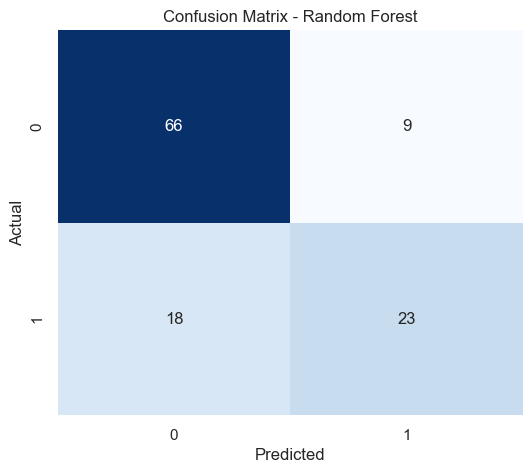

<Figure size 800x600 with 0 Axes>

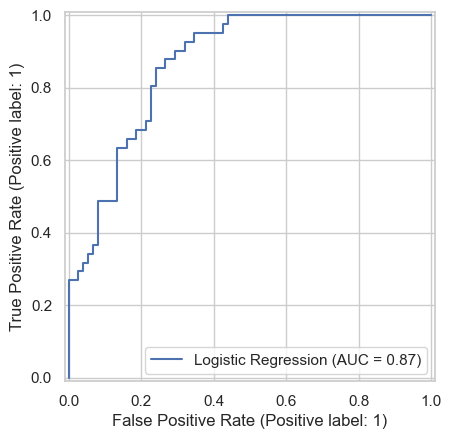

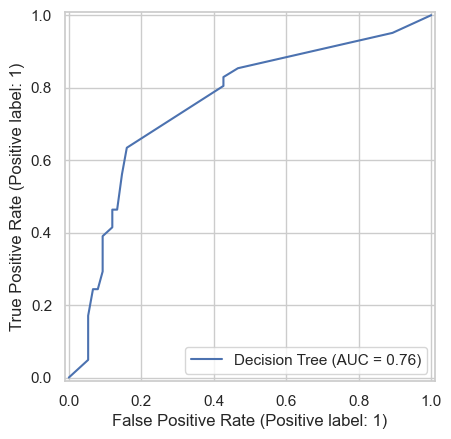

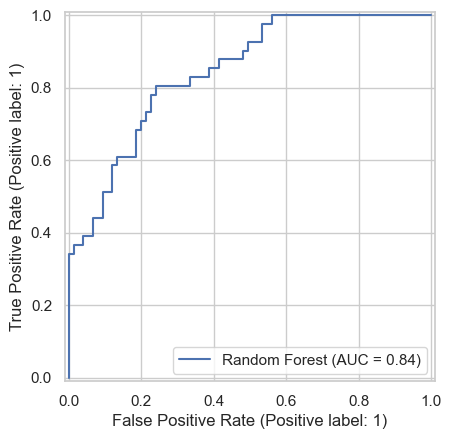

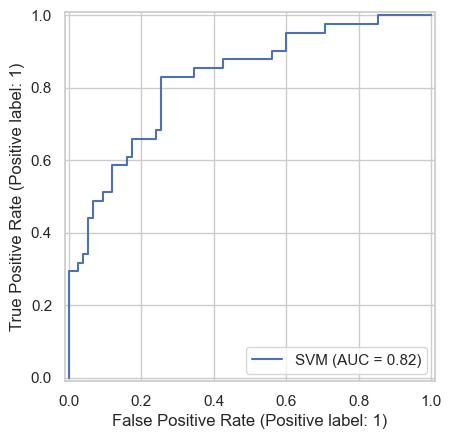

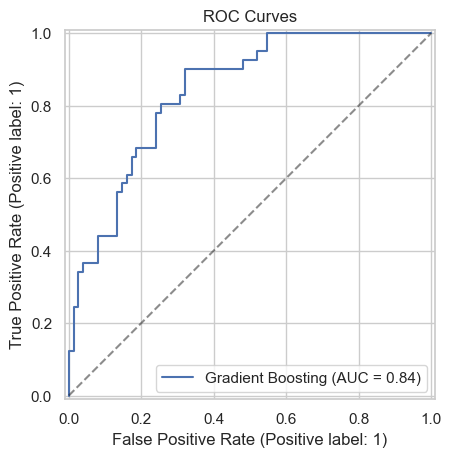

C:\Users\ACER\AppData\Local\Temp\ipykernel_20316\3239418489.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")


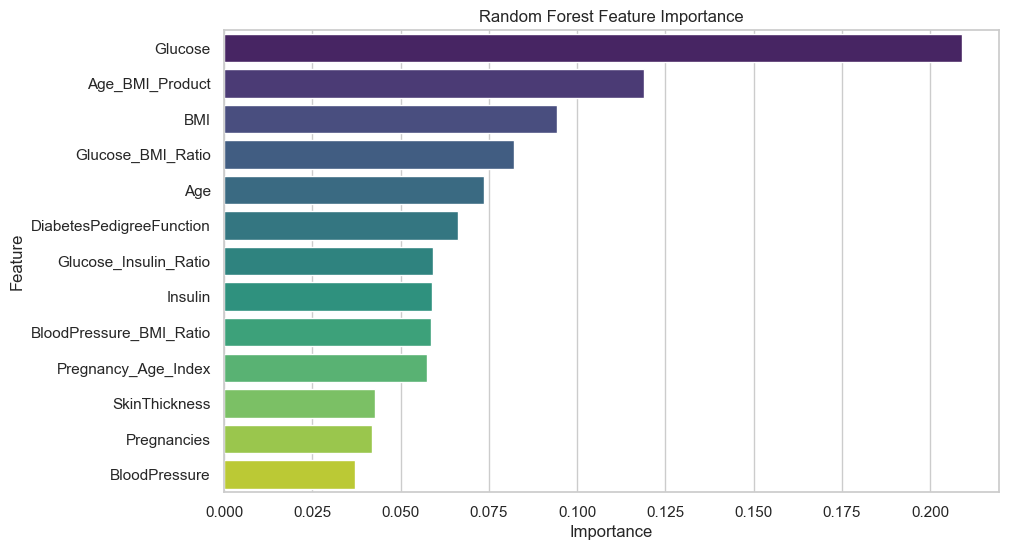

In [22]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
print(f"Best model by F1-score: {best_model_name}")

best_result = next(item for item in model_results if item["model"] == best_model_name)
cm = confusion_matrix(y_test, best_result["predictions"])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(8, 6))
for item in model_results:
    RocCurveDisplay.from_predictions(
        y_test,
        item["probabilities"],
        name=item["model"],
    )
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.title("ROC Curves")
plt.show()

rf_model = trained_models["Random Forest"]
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()